# RFM Customer Segmentation

---

**Author:** Raditya Zaki Athaya   
**Notebook:** `02_rfm_segmentation.ipynb`

---

## Project Overview

RFM Analysis adalah metode segmentasi pelanggan berbasis perilaku transaksi yang menggunakan tiga dimensi:

- **Recency (R):** Seberapa baru pelanggan melakukan transaksi terakhirnya.
- **Frequency (F):** Seberapa sering pelanggan melakukan pembelian.
- **Monetary (M):** Seberapa besar total pengeluaran pelanggan.

Tujuan notebook ini adalah mengubah data transaksi bersih menjadi profil skor RFM per pelanggan, lalu mengelompokkan mereka ke dalam segmen yang actionable — sehingga tim marketing dapat memprioritaskan strategi retensi, re-engagement, dan loyalitas secara lebih efisien.

## 1. Import Library & Load Data

Load dataset hasil cleaning dari notebook sebelumnya. Kolom `InvoiceDate` perlu dikonversi ulang ke tipe `datetime` karena proses export-import CSV mengubahnya kembali menjadi string.

In [ ]:
# ── Standard Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
import warnings

# ── Global Config ────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Load Cleaned Dataset ─────────────────────────────────────────────────────
CLEANED_PATH = '../data/processed/ecommerce_cleaned.csv'

df = pd.read_csv(CLEANED_PATH, dtype={'CustomerID': str, 'InvoiceNo': str})

# Re-konversi InvoiceDate ke datetime (CSV export mengubahnya jadi string)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Rentang tanggal: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
df.head()

Dataset loaded: 392,692 rows x 13 columns
Rentang tanggal: 2010-12-01 → 2011-12-09
Unique customers: 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,Year,Month,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Wednesday,8


## 2. Calculate RFM Metrics

Setiap pelanggan akan direpresentasikan oleh tiga nilai numerik:

| Metrik | Definisi | Cara Hitung |
|--------|----------|-------------|
| **Recency** | Berapa hari sejak transaksi terakhir | `reference_date - max(InvoiceDate)` |
| **Frequency** | Jumlah invoice unik yang pernah dibuat | `nunique(InvoiceNo)` |
| **Monetary** | Total nilai belanja sepanjang waktu | `sum(TotalSpend)` |

`reference_date` ditetapkan sebagai tanggal transaksi terakhir di dataset + 1 hari, agar semua pelanggan aktif memiliki Recency ≥ 1 hari (menghindari nilai 0).

In [2]:
# ── Tentukan Reference Date ───────────────────────────────────────────────────
# +1 hari dari tansaksi terakhir agar Recency minimal = 1 (tidak ada nilai 0)
reference_date = df['InvoiceDate'].max() + timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# ── Agregasi RFM per CustomerID ──────────────────────────────────────────────
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalSpend',  'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
print("\nDescriptive Statistics:")
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

Reference date: 2011-12-10

RFM table shape: (4338, 4)

Descriptive Statistics:


,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


## 3. RFM Scoring

Setiap metrik dibagi menjadi 5 kuantil menggunakan `pd.qcut`, menghasilkan skor 1–5 per dimensi.

Catatan penting pada **Recency**: nilai Recency yang **kecil** (transaksi baru-baru ini) justru lebih baik, sehingga urutan label dibalik — Recency terkecil mendapat skor **5**, bukan 1. Frequency dan Monetary mengikuti urutan normal (nilai besar = skor tinggi).

Skor akhir `RFM_Score` adalah gabungan string tiga digit, misalnya `"554"` atau `"213"`.

In [3]:
# ── Scoring dengan Kuantil (1–5) ─────────────────────────────────────────────
# Recency: skor dibalik — nilai kecil (baru transaksi) → skor tinggi
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# rank(method='first') digunakan pada Frequency untuk menghindari error
# apabila ada banyak nilai yang sama persis (duplicate bin edges pada qcut)

# ── Gabungkan Menjadi RFM_Score (string) ─────────────────────────────────────
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# ── Hitung RFM_Total sebagai skor agregat numerik ────────────────────────────
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("Scoring selesai.")
print(f"\nDistribusi RFM_Total:\n{rfm['RFM_Total'].value_counts().sort_index()}")
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total']].head(10)

Scoring selesai.

Distribusi RFM_Total:
RFM_Total
3     183
4     361
5     337
6     426
7     377
8     375
9     336
10    342
11    347
12    321
13    286
14    300
15    347
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,"77,183.60",1,1,5,115,7
1,12347,2,7,"4,310.00",5,5,5,555,15
2,12348,75,4,"1,797.24",2,4,4,244,10
3,12349,19,1,"1,757.55",4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,"2,506.04",3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,"1,079.40",1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,"2,811.43",4,3,5,435,12


## 4. Customer Segmentation

Skor RFM digunakan untuk memetakan setiap pelanggan ke dalam segmen yang bermakna secara bisnis. Pemetaan dilakukan berdasarkan kombinasi `R_Score` dan `F_Score` (dengan `M_Score` sebagai pendukung), menghasilkan 7 segmen:

| Segmen | Kriteria | Strategi |
|--------|----------|----------|
| **Champions** | R=5, F=4–5 | Reward & advocacy program |
| **Loyal Customers** | F=4–5, R=3–4 | Upsell & loyalty points |
| **Potential Loyalist** | R=4–5, F=2–3 | Onboarding & nurturing |
| **Promising** | R=3–4, F=1–2 | Early engagement offers |
| **At Risk** | R=2–3, F=3–5 | Win-back campaign |
| **Hibernating** | R=2–3, F=1–2 | Low-cost re-engagement |
| **Lost** | R=1, F=1–2 | Sunset / unsubscribe |

In [4]:
# ── Fungsi Pemetaan Segmen ────────────────────────────────────────────────────
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r == 5 and f >= 4:
        return 'Champions'
    elif f >= 4 and r >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 3:
        return 'Potential Loyalist'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r <= 3 and f >= 3:
        return 'At Risk'
    elif r <= 3 and f <= 2 and r >= 2:
        return 'Hibernating'
    else:
        return 'Lost'

# ── Aplikasikan ke DataFrame ──────────────────────────────────────────────────
rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ── Ringkasan Distribusi Segmen ───────────────────────────────────────────────
segment_counts = rfm['Segment'].value_counts()
print("Distribusi Pelanggan per Segmen:")
print(segment_counts.to_string())
print(f"\nTotal customers: {len(rfm):,}")

Distribusi Pelanggan per Segmen:
Segment
At Risk               829
Loyal Customers       827
Lost                  664
Champions             633
Potential Loyalist    633
Hibernating           401
Promising             351

Total customers: 4,338


## 5. RFM Distribution & Visualization

Visualisasi berikut membantu memahami komposisi pelanggan berdasarkan segmen dan rata-rata perilaku transaksi di tiap segmen.

In [5]:
# ── Aggregasi Rata-rata RFM per Segmen ────────────────────────────────────────
segment_summary = rfm.groupby('Segment').agg(
    Num_Customers = ('CustomerID',  'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean')
).round(2).sort_values('Num_Customers', ascending=False).reset_index()

print("Segment Summary:")
print(segment_summary.to_string(index=False))

Segment Summary:
           Segment  Num_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
           At Risk            829       130.46           3.16      1,161.06
   Loyal Customers            827        33.47           6.46      2,848.33
              Lost            664       278.08           1.06        475.09
         Champions            633         5.88          12.41      6,843.16
Potential Loyalist            633        17.43           1.79        881.46
       Hibernating            401       118.25           1.16        505.89
         Promising            351        53.50           1.16        459.00


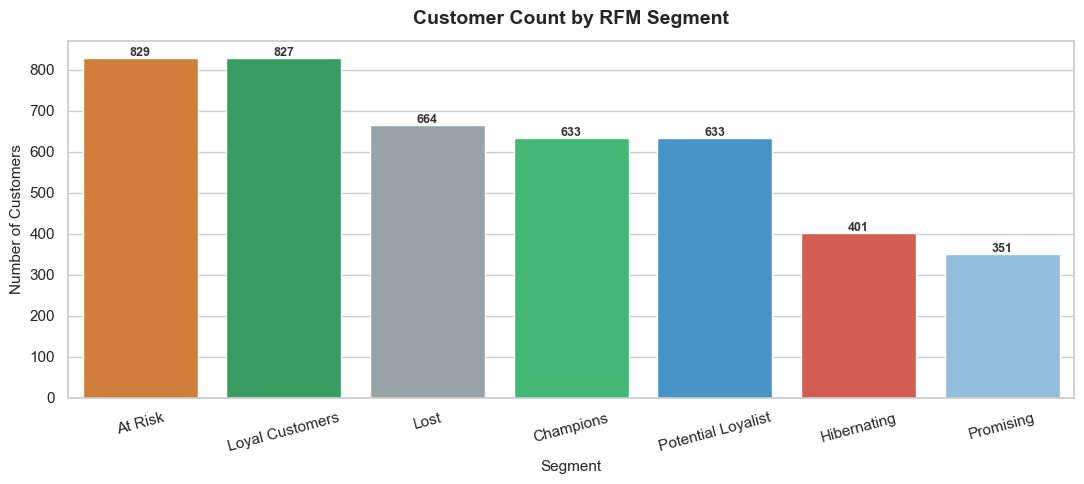

In [6]:
# ── Plot 1: Jumlah Pelanggan per Segmen ───────────────────────────────────────
SEGMENT_ORDER = segment_summary['Segment'].tolist()
PALETTE = {
    'Champions':         '#2ecc71',
    'Loyal Customers':   '#27ae60',
    'Potential Loyalist':'#3498db',
    'Promising':         '#85c1e9',
    'At Risk':           '#e67e22',
    'Hibernating':       '#e74c3c',
    'Lost':              '#95a5a6'
}

fig, ax = plt.subplots(figsize=(11, 5))

bars = sns.barplot(
    data=segment_summary,
    x='Segment', y='Num_Customers',
    palette=PALETTE,
    order=SEGMENT_ORDER,
    ax=ax
)

# Label nilai di atas bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{int(bar.get_height()):,}",
        ha='center', fontsize=9, fontweight='bold', color='#333333'
    )

ax.set_title('Customer Count by RFM Segment', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Segment', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

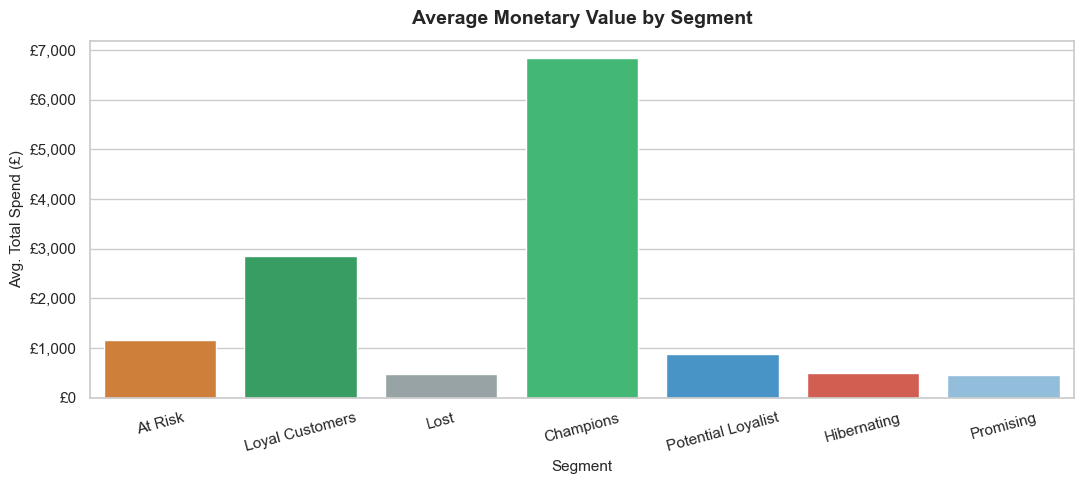

In [7]:
# ── Plot 2: Rata-rata Monetary per Segmen ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=segment_summary,
    x='Segment', y='Avg_Monetary',
    palette=PALETTE,
    order=SEGMENT_ORDER,
    ax=ax
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Average Monetary Value by Segment', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Segment', fontsize=11)
ax.set_ylabel('Avg. Total Spend (£)', fontsize=11)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

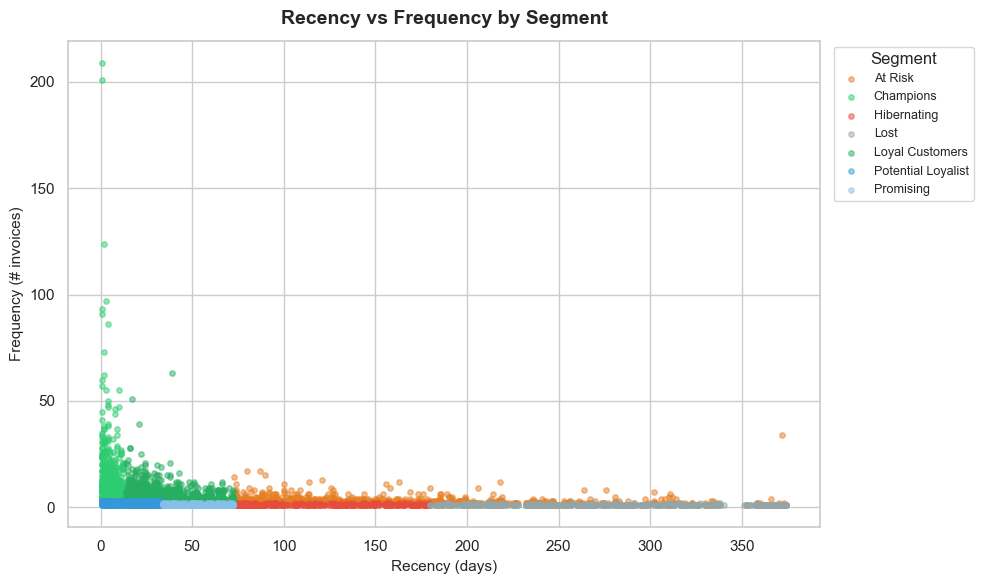

In [8]:
# ── Plot 3: Scatter Recency vs Frequency, warna per Segmen ───────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for segment, group in rfm.groupby('Segment'):
    ax.scatter(
        group['Recency'], group['Frequency'],
        label=segment,
        alpha=0.5, s=15,
        color=PALETTE.get(segment, '#999999')
    )

ax.set_title('Recency vs Frequency by Segment', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Recency (days)', fontsize=11)
ax.set_ylabel('Frequency (# invoices)', fontsize=11)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Export RFM Data

Hasil segmentasi RFM disimpan ke `data/processed/rfm_segments.csv` sebagai input untuk visualisasi dashboard atau analisis lanjutan.

In [9]:
# ── Export RFM Segments ───────────────────────────────────────────────────────
OUTPUT_PATH = '../data/processed/rfm_segments.csv'

rfm.to_csv(OUTPUT_PATH, index=False)

print(f"RFM data saved to: {OUTPUT_PATH}")
print(f"Shape: {rfm.shape[0]:,} rows x {rfm.shape[1]} columns")
print("\nFinal columns:")
for col in rfm.columns:
    print(f"  - {col} ({rfm[col].dtype})")

RFM data saved to: ../data/processed/rfm_segments.csv
Shape: 4,338 rows x 10 columns

Final columns:
  - CustomerID (object)
  - Recency (int64)
  - Frequency (int64)
  - Monetary (float64)
  - R_Score (int32)
  - F_Score (int32)
  - M_Score (int32)
  - RFM_Score (object)
  - RFM_Total (int32)
  - Segment (object)
